# NGSolve：经典 CEM 与 Robin CEM / Classic CEM versus Robin CEM

## 目标 / Goal

| 中文 | English |
|---|---|
| 导入与 PyEIDORS、EIDORS 相同的 X01 Gmsh 网格，用 NGSolve 组装 $A_R,C,D$，逐步运行两种数学等价的 CEM 求解方法，再把 NGSolve 的 `float64` 电压与同一个 $\mathbb{Q}$ 有理数精确参考解比较。 | Import the same canonical X01 Gmsh mesh used by PyEIDORS and EIDORS, assemble $A_R,C,D$ with NGSolve, step through both mathematically equivalent CEM solvers, and compare NGSolve's `float64` voltage with the same certified exact reference over $\mathbb{Q}$. |


## 设置 / Setup

| 中文 | English |
|---|---|
| 按 `README.md` 在隔离的 NGSolve 环境中启动本 Notebook。小型可移植 X01 MSH/JSON 夹具不依赖完整 38 案例预生成结果。 | Launch this notebook in the isolated NGSolve environment described in `README.md`. The portable X01 MSH/JSON fixture works before the complete 38-case suite is prepared. |


In [1]:
from pathlib import Path
import json
import sys

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name != "cem_exact_extension_walkthrough":
    NOTEBOOK_DIR = Path("examples/cem_exact_extension_walkthrough").resolve()
REPO_ROOT = NOTEBOOK_DIR.parents[1]
for path in (REPO_ROOT, NOTEBOOK_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
from matplotlib import font_manager  # noqa: E402

from experiment_common import (  # noqa: E402
    build_classic_state,
    build_robin_state,
    exact_reference_metrics,
    formulation_diagnostics,
    load_assembled_blocks,
    load_csv_records,
    load_forward_fixture,
    load_portable_exact_reference,
    plot_forward_fixture,
    plot_forward_solution,
    solve_classic,
    solve_robin,
    summarize_accuracy_records,
)
from ngsolve_debug import resolve_fixture  # noqa: E402
from scripts.benchmarks.ngsolve_cem_exact_extension_case import run_case  # noqa: E402

for font_path in (
    Path("/mnt/c/Windows/Fonts/times.ttf"),
    Path("/mnt/c/Windows/Fonts/timesbd.ttf"),
    Path("/mnt/c/Windows/Fonts/msyh.ttc"),
):
    if font_path.exists():
        font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = ["Times New Roman", "Microsoft YaHei"]

/home/tom/.cache/uv/archive-v0/uFrpue222jf3oC5A4lkzg/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# 选择案例和计时重复次数 / Select the case and timing repetitions.
CASE_ID = "X01"
REGENERATE = False
TIMING_REPEATS = 11
SUITE_OUTPUT = REPO_ROOT / "output" / "cem_exact_extension"
REFERENCE_PATH = NOTEBOOK_DIR / "fixtures" / "X01" / "exact_reference.json"
METRICS_PATH = NOTEBOOK_DIR / "expected" / "cem_exact_extension_metrics.csv"
FIGURE_DIR = NOTEBOOK_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 符号与变量字典 / Symbol and variable dictionary

| 变量或符号 | 中文含义 | English meaning | 类型或维度 |
|---|---|---|---|
| `CASE_ID` | 当前正问题案例编号；默认 `X01` 是均匀背景电导率案例。 | Selected forward-problem case; default `X01` has uniform background conductivity. | `str` |
| `fixture` / `metadata_path` | 三个框架共用的规范输入：节点、三角形、电极边、逐单元电导率、接触阻抗和电流模式。 | Canonical input shared by all three frameworks: nodes, triangles, electrode edges, cell conductivity, contact impedance, and drives. | 路径和元数据 / paths and metadata |
| `NGSolve_report` | NGSolve 正式运行器保存的求解器、离散化、计时和原始电压报告。 | Solver, discretization, timing, and raw-voltage report saved by the official NGSolve runner. | `dict` |
| $N$ | 有限元体节点数。 | Number of FEM body nodes. | `int` |
| $K$ | 三角形单元数。 | Number of triangular cells. | `int` |
| $L$ | 电极数。 | Number of electrodes. | `int` |
| $P$ | 同时求解的电流模式（右端项）数。 | Number of current patterns/right-hand sides. | `int` |
| `nodes` | 每个体节点的 $(x,y)$ 坐标。 | $(x,y)$ coordinate of every body node. | $N\times2$ |
| `cells` | 每个 P1 三角形的三个节点索引。 | Three node indices of every P1 triangle. | $K\times3$ |
| `tagged_edges` | 边界边的两个节点及其电极标签；标签 0 表示绝缘边。 | Two vertices and electrode label for each boundary edge; label 0 is insulating. | $E_b\times3$ |
| `cell_conductivity`, $\sigma_k$ | 单元电导率：第 $k$ 个三角形内的常数值；X01 全部为 $1/8$。 | Cell conductivity: the constant value in cell $k$; every X01 cell is $1/8$. | $K$ 个标量 / $K$ scalars |
| `contact_impedance`, $z_\ell$ | 第 $\ell$ 个电极的接触阻抗；X01 为 1。 | Contact impedance of electrode $\ell$; X01 uses 1. | $L$ 个标量 / $L$ scalars |
| `blocks.currents`, $I$ | 边界注入电流；每一列严格满足 $\mathbf{1}^\mathsf{T}I_{:,p}=0$。 | Injected current on the boundary; every column satisfies $\mathbf{1}^\mathsf{T}I_{:,p}=0$. | $L\times P$ |
| `blocks.robin_matrix`, $A_R$ | 体刚度矩阵加电极 Robin 边界质量项。 | Body stiffness matrix plus the electrode Robin boundary mass. | N×N 稀疏矩阵 |
| `blocks.coupling`, $C$ | 体节点自由度与常数电极电势之间的耦合。 | Coupling between body nodal DOFs and constant electrode voltages. | N×L 稀疏矩阵 |
| `blocks.electrode_matrix`, $D$ | 电极边界积分形成的电极块。 | Electrode block from boundary integrals. | L×L 稀疏矩阵 |
| $u$ | 每个电流模式对应的体内节点电势。 | Body nodal potential for each drive. | $N$×$P$ |
| $U$ | 每个电流模式对应的边界电极电压，也是本实验比较的主要输出。 | Boundary electrode voltage for each drive; the principal compared output. | $L$×$P$ |
| $\lambda$ | 传统 CEM 中实施 $\mathbf{1}^\mathsf{T}U=0$ 的拉格朗日乘子。 | Gauge multiplier enforcing $\mathbf{1}^\mathsf{T}U=0$ in Classic CEM. | $1$×$P$ |
| $Q$ | `float64` 求解中电极零和子空间的正交基。 | Orthonormal basis of the zero-sum electrode subspace in the `float64` solve. | $L$×$(L-1)$ |
| $y$ | 电极电压在零和基中的坐标，满足 $U=Qy$。 | Coordinates of electrode voltage in the zero-sum basis, with $U=Qy$. | $(L-1)$×$P$ |
| `response_basis`, $R$ | 解 $A_RR=CQ$ 得到的体响应基；代码用分解求解，不显式形成逆矩阵。 | Body response basis from $A_RR=CQ$; solved by a factorization without forming an inverse. | $N$×$(L-1)$ |
| `schur_action_basis` | $DQ-C^\mathsf{T}R$，即完整跨导算子作用在 $Q$ 上的结果。 | $DQ-C^\mathsf{T}R$, the full transconductance action on $Q$. | $L$×$(L-1)$ |
| `reduced_map`, $T_r$ | $Q^\mathsf{T}(DQ-C^\mathsf{T}R)$，Robin CEM 实际分解的小矩阵。 | $Q^\mathsf{T}(DQ-C^\mathsf{T}R)$, the small matrix actually factored by Robin CEM. | $(L-1)$×$(L-1)$ |
| `nnz` | 稀疏矩阵中非零元素数量，不是误差。 | Number of stored nonzeros in a sparse matrix; it is not an error metric. | `int` |
| `mesh_fingerprint` | 网格指纹：对规范节点、单元和带标签边界边计算的 SHA-256；三个报告必须一致。 | Mesh fingerprint: SHA-256 of canonical nodes, cells, and tagged boundary edges; all three reports must match it. | 64 位十六进制 / hex chars |

### 38 个案例究竟计算什么 / What the 38 cases compute

每个案例都是 **CEM 正问题**，不是逆问题重构：给定同一案例的网格、
逐单元电导率、电极、接触阻抗和零和电流模式，分别用传统 CEM 与 Robin CEM
计算体内节点电势 $u$ 和边界电极电压 $U$。每个框架必须先画出自己实际加载的
网格、$\sigma_k$ 和选定的边界注流，并通过相同网格指纹认证，之后结果才进入
跨框架比较。

Every case is a **CEM forward problem**, not an inverse reconstruction:
given the case's mesh, cell conductivity, electrodes, contact impedance, and
zero-sum drives, Classic and Robin CEM compute body potential $u$ and boundary
electrode voltage $U$. Each framework must first display the mesh,
$\sigma_k$, and a selected boundary drive that it actually loaded, and must
certify the same mesh fingerprint before its result enters the cross-framework
comparison.

| 案例 | 正问题设置 / Forward setting | 主要用途 / Purpose |
|---|---|---|
| X01–X16 | Q0/Q2 网格；16 电极；均匀有理 $\sigma$；多种有理 $z$；相邻和 skip-4 注流。 | 改变网格、物性范围、接触阻抗和注流跨度。 / Vary mesh, physical range, impedance, and drive span. |
| X17–X24 | Q0/Q2 网格；16 电极；左右两区 $\sigma=1/4$ 与 $1$；两种 $z$ 和注流。 | 表示已知内部非均匀待测物后的正向边界电压。 / Forward voltages for a known internal heterogeneity. |
| X25–X32 | Q0/Q2 网格；8 电极；均匀 $\sigma=1/4$；两种 $z$ 和注流。 | 检查电极数改变。 / Check a different electrode count. |
| X33–X38 | 更细 Q4 网格；16 电极；均匀 $\sigma=1/4$；三种 $z$ 和两种注流。 | 检查更大有理离散系统。 / Check the larger rational discretization. |


## 步骤 / Steps

### 1. 用 NGSolve 组装规范夹具 / Assemble the canonical fixture with NGSolve

| 中文 | English |
|---|---|
| NGSolve 报告记录导入网格指纹、材料电导率摘要、P1 阶次和 `float64` 求解器元数据，用来证明三个框架使用同一个离散问题。 | The NGSolve report records the imported mesh fingerprint, material-conductivity digest, P1 order, and `float64` solver metadata, proving that the three frameworks use the same discrete problem. |


In [3]:
mesh_path, metadata_path, case_dir = resolve_fixture(CASE_ID, SUITE_OUTPUT)
case_dir.mkdir(parents=True, exist_ok=True)
report_path = case_dir / "ngsolve_report.json"
block_path = case_dir / "ngsolve_assembled_blocks.mat"

if REGENERATE or not report_path.exists() or not block_path.exists():
    ngsolve_report = run_case(
        mesh_path,
        metadata_path,
        report_path,
        timing_repeats=TIMING_REPEATS,
    )
else:
    ngsolve_report = json.loads(report_path.read_text(encoding="utf-8"))

blocks = load_assembled_blocks(block_path)
forward_fixture = load_forward_fixture(
    metadata_path.with_suffix(".mat"),
    metadata_path,
)
solver_mesh_fingerprint = ngsolve_report["discretization"]["mesh_fingerprint"]
assert forward_fixture.mesh_fingerprint == solver_mesh_fingerprint
{
    "mesh": str(mesh_path),
    "N_nodes": forward_fixture.nodes.shape[0],
    "K_cells": forward_fixture.cells.shape[0],
    "L_electrodes": forward_fixture.electrode_count,
    "P_current_patterns": forward_fixture.currents.shape[1],
    "potential_order": forward_fixture.potential_order,
    "scalar_dtype": forward_fixture.scalar_dtype,
    "conductivity_pattern": forward_fixture.conductivity_pattern,
    "unique_cell_conductivity": np.unique(forward_fixture.cell_conductivity),
    "contact_impedance_exact": forward_fixture.contact_impedance_exact,
    "first_current_pattern": forward_fixture.currents[:, 0],
    "current_column_sums": np.sum(forward_fixture.currents, axis=0),
    "A_R_shape": blocks.robin_matrix.shape,
    "A_R_nnz": blocks.robin_matrix.nnz,
    "C_shape": blocks.coupling.shape,
    "D_shape": blocks.electrode_matrix.shape,
    "mesh_fingerprint": solver_mesh_fingerprint,
}

{'mesh': '/home/tom/workspace/PyEidors_wsl2/output/cem_exact_extension/cases/X01_range_q0_uniform_sigma_1_8_to_1_8_z_1_adjacent/common_mesh/cem_exact_extension_p1.msh',
 'N_nodes': 33,
 'K_cells': 32,
 'L_electrodes': 16,
 'P_current_patterns': 16,
 'potential_order': 1,
 'scalar_dtype': 'float64',
 'conductivity_pattern': 'uniform',
 'unique_cell_conductivity': array([0.125]),
 'contact_impedance_exact': '1',
 'first_current_pattern': array([ 1., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.]),
 'current_column_sums': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'A_R_shape': (33, 33),
 'A_R_nnz': 161,
 'C_shape': (33, 16),
 'D_shape': (16, 16),
 'mesh_fingerprint': '7be7165ad3bdd3661ae06bea768622741ece609acde5720f3dd0c0cbde85c5bc'}

### 2. 显示公平的正问题条件 / Display the fair forward conditions

| 中文 | English |
|---|---|
| NGSolve 使用的 MSH 与下面绘图读取的同名 MAT/JSON 由同一个规范有理夹具同时导出。左图显示 P1 网格和逐单元电导率，右图显示第一个边界电流模式。 | The NGSolve MSH and the same-stem MAT/JSON used below were exported together from one canonical rational fixture. The left panel shows the P1 mesh and per-cell conductivity; the right panel shows the first boundary-current pattern. |
| X01 计算的是均匀背景正问题：输入网格、$\sigma=1/8$、$z=1$ 和相邻电流模式，输出 $u$ 与电极电压 $U$；它不是逆问题重构。 | X01 solves a uniform-background forward problem: the mesh, $\sigma=1/8$, $z=1$, and adjacent drives are inputs, while $u$ and electrode voltage $U$ are outputs. It is not an inverse reconstruction. |


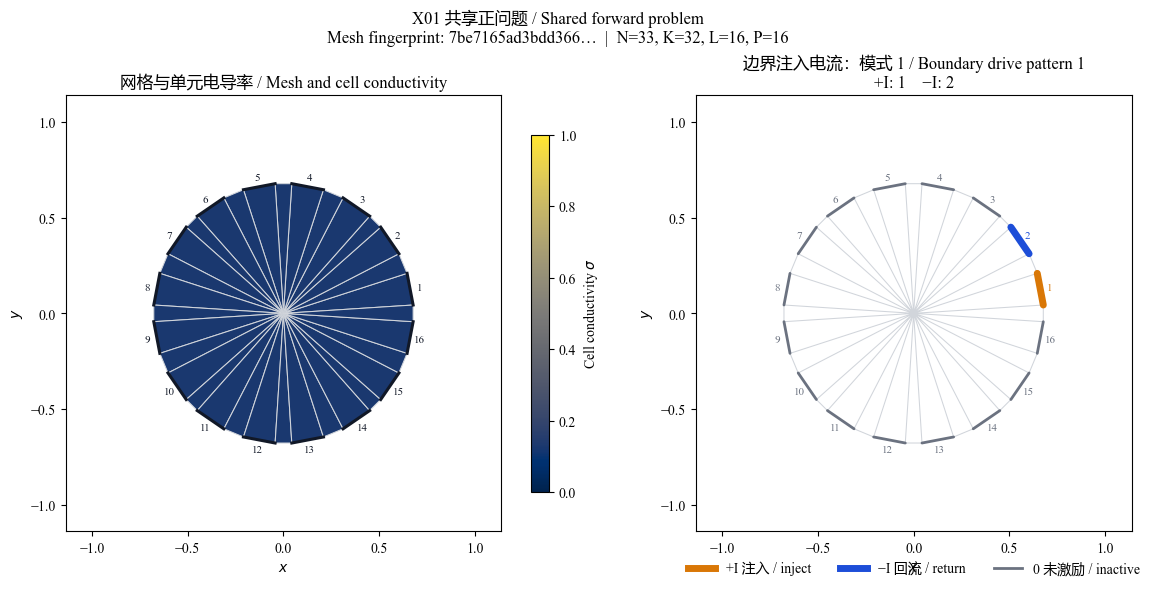

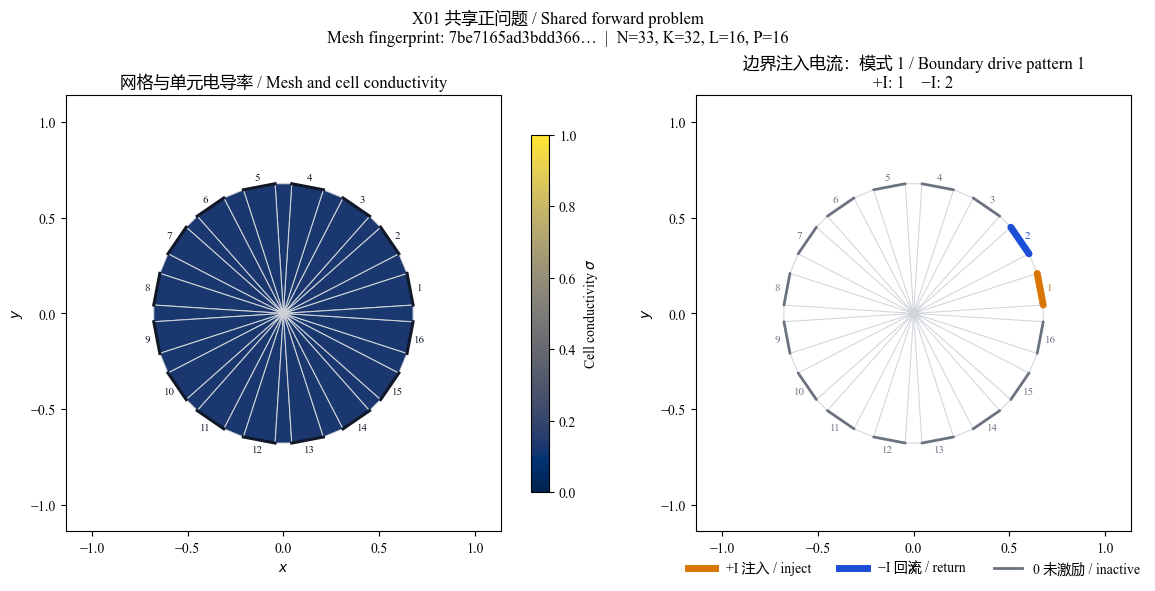

In [4]:
fairness_figure, fairness_axes = plot_forward_fixture(
    forward_fixture,
    current_column=0,
)
fairness_figure.savefig(
    FIGURE_DIR / f"{CASE_ID}_ngsolve_forward_setup.png",
    dpi=180,
    bbox_inches="tight",
)
fairness_figure

### 3. 传统经典 CEM / Traditional Classic CEM

| 中文 | English |
|---|---|
| 分解完整的增广稀疏矩阵，并一次求解所有电流列。 | Factor the complete augmented sparse matrix and solve all current columns. |

$$
\begin{bmatrix}
A_R & C & 0 \\
C^\mathsf{T} & D & \mathbf{1} \\
0 & \mathbf{1}^\mathsf{T} & 0
\end{bmatrix}
\begin{bmatrix}
u \\ U \\ \lambda
\end{bmatrix}
=
\begin{bmatrix}
0 \\ I \\ 0
\end{bmatrix}.
$$


In [5]:
classic_state = build_classic_state(blocks)
classic_solution = solve_classic(classic_state, blocks.currents)
{
    "augmented_shape": classic_state.system_matrix.shape,
    "augmented_nnz": classic_state.system_matrix.nnz,
    "voltage_shape": classic_solution.electrode_voltage.shape,
}

{'augmented_shape': (50, 50), 'augmented_nnz': 273, 'voltage_shape': (16, 16)}

### 4. Robin/跨导 CEM / Robin/transconductance CEM

| 中文 | English |
|---|---|
| 分解 $A_R$，构造响应基 $R=A_R^{-1}CQ$ 和约化映射 $T_r$，再求解 $L-1$ 维电极问题。 | Factor $A_R$, construct the response basis $R=A_R^{-1}CQ$ and reduced map $T_r$, then solve the $L-1$ dimensional electrode problem. |

$$
R=A_R^{-1}CQ,\qquad
T_r=Q^\mathsf{T}\left(DQ-C^\mathsf{T}R\right)
=Q^\mathsf{T}\left(D-C^\mathsf{T}A_R^{-1}C\right)Q.
$$

$$
T_r y=Q^\mathsf{T}I,\qquad
U=Qy,\qquad
u=-Ry.
$$


In [6]:
robin_state = build_robin_state(blocks)
robin_solution = solve_robin(robin_state, blocks.currents)
{
    "Q_shape": robin_state.electrode_basis.shape,
    "response_basis_shape": robin_state.response_basis.shape,
    "reduced_map_shape": robin_state.reduced_map.shape,
    "reduced_condition_number": np.linalg.cond(robin_state.reduced_map),
}

{'Q_shape': (16, 15),
 'response_basis_shape': (33, 15),
 'reduced_map_shape': (15, 15),
 'reduced_condition_number': np.float64(3.972405454523264)}

### 5. 浮点等价性诊断 / Floating-point equivalence diagnostics

| 中文 | English |
|---|---|
| 这里比较同一个 NGSolve 分块经过两条不同线性代数路径后得到的电极电压、体电势、缩放后向残差和零均值规范残差。 | This section compares electrode voltages, body potentials, scaled backward residuals, and zero-mean gauge residuals from the two algebraic routes applied to the same NGSolve blocks. |


In [7]:
solutions = {
    "classic": classic_solution,
    "robin_transconductance": robin_solution,
}
diagnostics = formulation_diagnostics(blocks, solutions)
diagnostics

{'electrode_voltage_relative_l2': 6.622413604423196e-16,
 'body_potential_relative_l2': 1.7005165240299826e-15,
 'classic_scaled_backward_residual': 1.3327017019220574e-17,
 'robin_scaled_backward_residual': 5.664218387585743e-17,
 'classic_voltage_gauge_max_abs': 2.220446049250313e-15,
 'robin_voltage_gauge_max_abs': 4.322930902134203e-15}

### 6. 求解结果可视化 / Forward-result visualization

| 中文 | English |
|---|---|
| 上排比较同一个 NGSolve 分块得到的 Classic 体电势、Robin 体电势与体电势差值 `Robin − Classic`；下排显示两个电极电压序列及舍入级差值。Classic 与 Robin 主结果使用共同色标和共同纵轴，因此不能靠不同的自动缩放制造视觉差异。 | The top row compares Classic body potential, Robin body potential, and the `Robin − Classic` body-potential difference from the same NGSolve blocks. The bottom row shows both electrode-voltage sequences and their roundoff-level difference. Shared colour and voltage limits prevent separate autoscaling from manufacturing a visual discrepancy. |
| 图中数据就是上一单元 `diagnostics` 使用的 `solutions`，没有额外插值到另一张网格。 | The plotted data are the same `solutions` used by the preceding diagnostics, without interpolation to another mesh. |


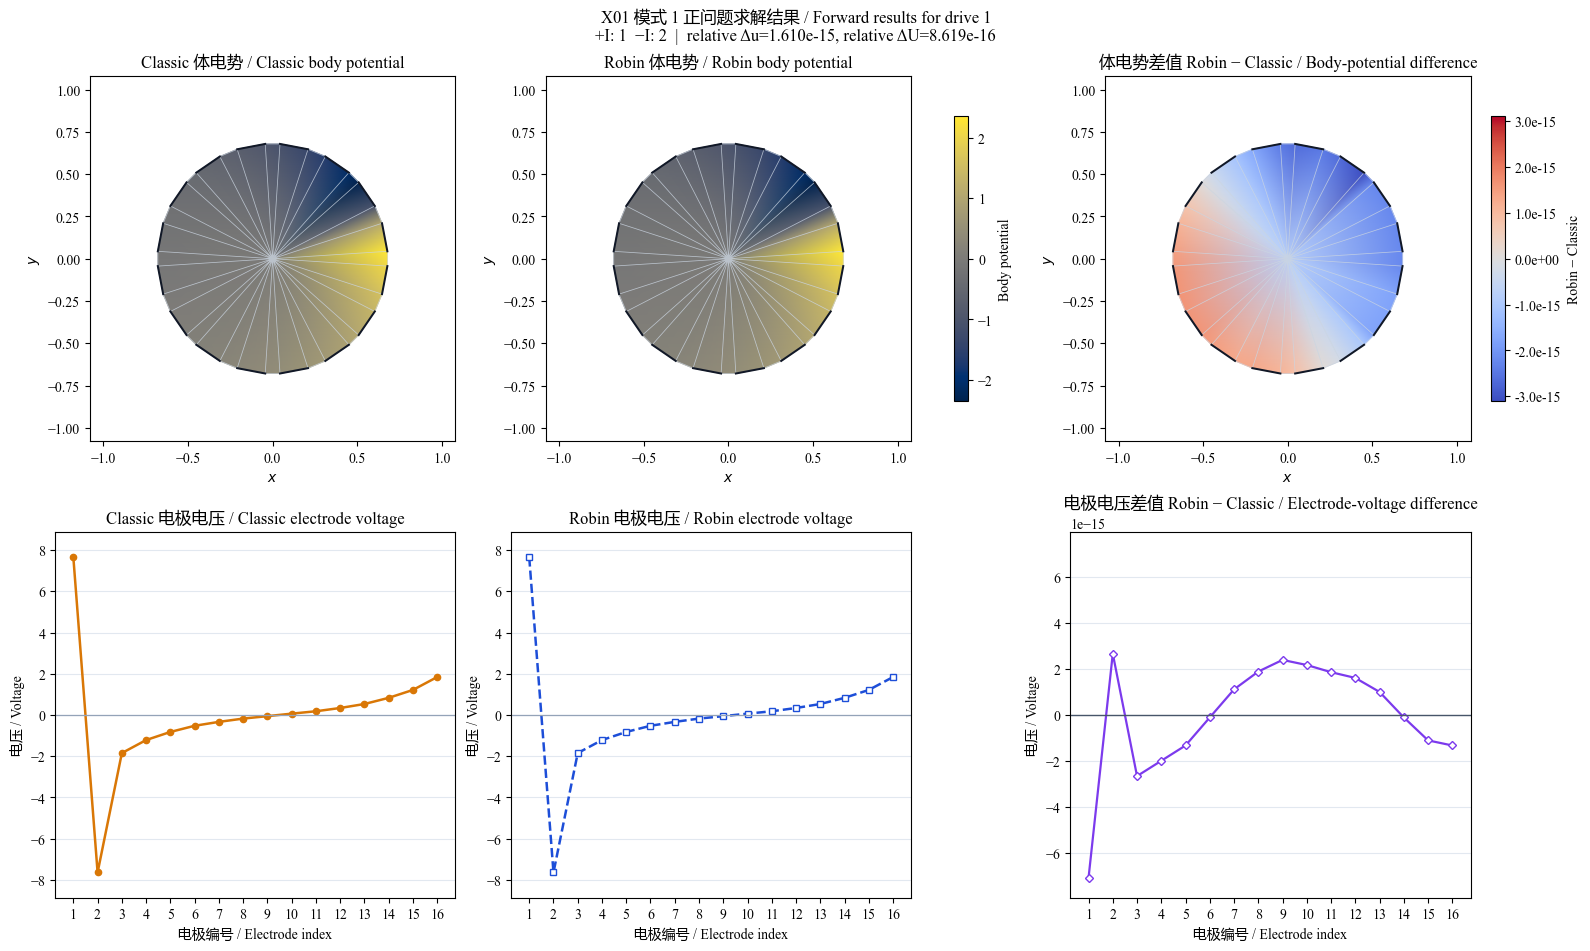

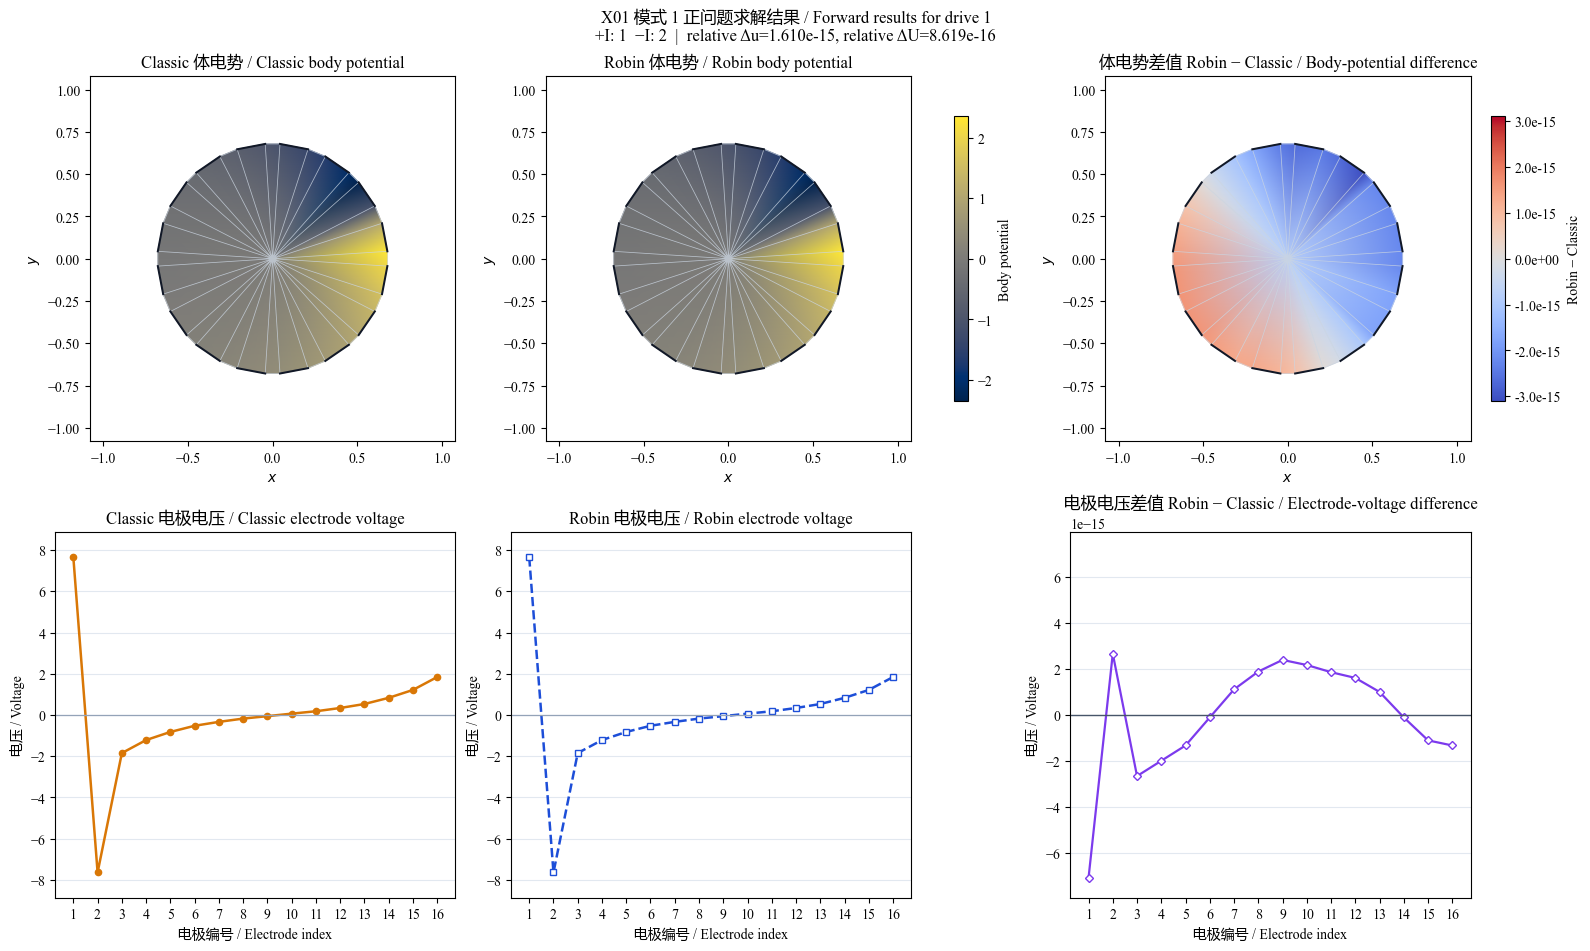

In [8]:
result_figure, result_axes = plot_forward_solution(
    forward_fixture,
    solutions,
    current_column=0,
)
result_figure.savefig(
    FIGURE_DIR / f"{CASE_ID}_ngsolve_classic_robin_results.png",
    dpi=180,
    bbox_inches="tight",
)
result_figure

Font 'default' does not have a glyph for '\u7ea6' [U+7ea6], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5316' [U+5316], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6620' [U+6620], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5c04' [U+5c04], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7ea6' [U+7ea6], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5316' [U+5316], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6620' [U+6620], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5c04' [U+5c04], substituting with a dummy symbol.


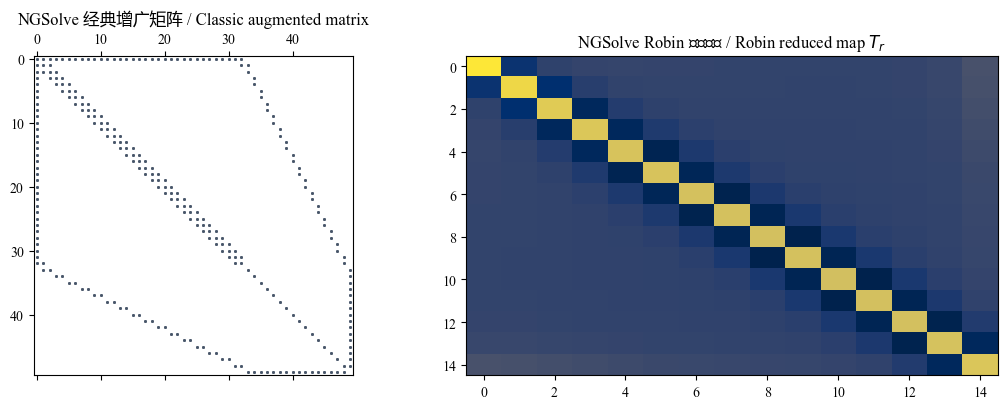

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].spy(classic_state.system_matrix, markersize=1.1, color="#475569")
axes[0].set_title("NGSolve 经典增广矩阵 / Classic augmented matrix")
axes[1].imshow(robin_state.reduced_map, cmap="cividis", aspect="auto")
axes[1].set_title("NGSolve Robin 约化映射 / Robin reduced map $T_r$")
fig.tight_layout()

### 7. 相对于有理数精确电压的误差 / Accuracy relative to the exact rational voltage

| 中文 | English |
|---|---|
| 与 PyEIDORS 使用相同的分数形式精确参考解；这样求解器误差不会被另一个双精度“真值”污染。 | Use the same fraction-valued exact reference as PyEIDORS, so solver error is not contaminated by another double-precision “truth”. |

$$
\varepsilon_{\mathrm{truth}}
=\frac{\left\|U_{\mathrm{float64}}-U_{\mathbb{Q}}\right\|_F}
{\left\|U_{\mathbb{Q}}\right\|_F}.
$$


In [10]:
exact_reference = load_portable_exact_reference(REFERENCE_PATH)
exact_metrics = {
    name: exact_reference_metrics(solution.electrode_voltage, exact_reference)
    for name, solution in solutions.items()
}
exact_metrics

{'classic': {'truth_relative_l2': 5.164183627234171e-15,
  'truth_max_abs': 3.5316307155908586e-14,
  'exact_reduced_scaled_backward_residual': 3.346608907457746e-16,
  'voltage_gauge_relative_residual': 6.613077203285321e-17,
  'reduced_condition_number_2_estimate': 47.697807812864},
 'robin_transconductance': {'truth_relative_l2': 5.13760176751985e-15,
  'truth_max_abs': 3.5316307155908586e-14,
  'exact_reduced_scaled_backward_residual': 3.322362874740091e-16,
  'voltage_gauge_relative_residual': 1.1659400088481507e-16,
  'reduced_condition_number_2_estimate': 47.697807812864}}

## 检查 / Checks

| 中文 | English |
|---|---|
| 显式教学求解路径必须逐位复现正式 NGSolve 案例运行器保存的电极电压，否则立即失败。 | The explicit walkthrough path must reproduce the electrode voltage stored by the official NGSolve case runner exactly; otherwise it fails immediately. |


In [11]:
stored_voltages = {
    name: np.asarray(values, dtype=np.float64)
    for name, values in ngsolve_report["raw_electrode_voltages"].items()
}
assert np.array_equal(
    classic_solution.electrode_voltage,
    stored_voltages["classic"],
)
assert np.array_equal(
    robin_solution.electrode_voltage,
    stored_voltages["robin_transconductance"],
)
"All selected-case checks passed."

'All selected-case checks passed.'

### 复现 38 个案例的报告数字 / Reproduce the 38-case report numbers

| 中文 | English |
|---|---|
| 使用相同的冻结 228 条精度记录复算三个框架、两种公式的汇总指标。 | Recompute the three-framework, two-formulation summary from the same 228 frozen accuracy records. |


In [12]:
summary = summarize_accuracy_records(load_csv_records(METRICS_PATH))
{
    "record_count": summary["record_count"],
    "case_count": summary["case_count"],
    "geometric_means": summary["geometric_means"],
    "win_counts": summary["win_counts"],
    "q4_summary": summary["q4_summary"],
}

{'record_count': 228,
 'case_count': 38,
 'geometric_means': {'classic': {'EIDORS': 1.6935476890754599e-15,
   'NGSolve': 1.1200923250127873e-14,
   'PyEIDORS/DOLFINx': 1.1094109141135253e-15},
  'robin_transconductance': {'EIDORS': 1.7352953602888227e-15,
   'NGSolve': 1.0751276317956813e-14,
   'PyEIDORS/DOLFINx': 1.0595913702941103e-15}},
 'win_counts': {'classic': {'EIDORS': 11,
   'NGSolve': 0,
   'PyEIDORS/DOLFINx': 27},
  'robin_transconductance': {'EIDORS': 9,
   'NGSolve': 0,
   'PyEIDORS/DOLFINx': 29}},
 'q4_summary': {'classic': {'case_ids': ['X33',
    'X34',
    'X35',
    'X36',
    'X37',
    'X38'],
   'same_order_all_cases': True,
   'ordering': ['PyEIDORS/DOLFINx', 'EIDORS', 'NGSolve']},
  'robin_transconductance': {'case_ids': ['X33',
    'X34',
    'X35',
    'X36',
    'X37',
    'X38'],
   'same_order_all_cases': True,
   'ordering': ['PyEIDORS/DOLFINx', 'EIDORS', 'NGSolve']}}}

## 后续步骤 / Next Steps

| 中文 | English |
|---|---|
| 1. 先运行 PyEIDORS `prepare` 生成全部 38 个共享夹具。<br>2. 运行 `ngsolve_debug.py --all --timing-repeats 11`。<br>3. 在 `assemble_extension_blocks`、`build_classic_state` 和 `build_robin_state` 设置断点。<br>4. 只有三个框架的报告全部存在后才运行 Python `compare`。 | 1. Run PyEIDORS `prepare` to generate all 38 common fixtures.<br>2. Run `ngsolve_debug.py --all --timing-repeats 11`.<br>3. Set VS Code breakpoints in `assemble_extension_blocks`, `build_classic_state`, and `build_robin_state`.<br>4. Run Python `compare` only after all PyEIDORS, NGSolve, and EIDORS reports exist. |
